In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

%matplotlib inline
plt.style.use("seaborn-v0_8-whitegrid")

C:\Users\ana\AppData\Local\Temp\ipykernel_12828\95627986.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


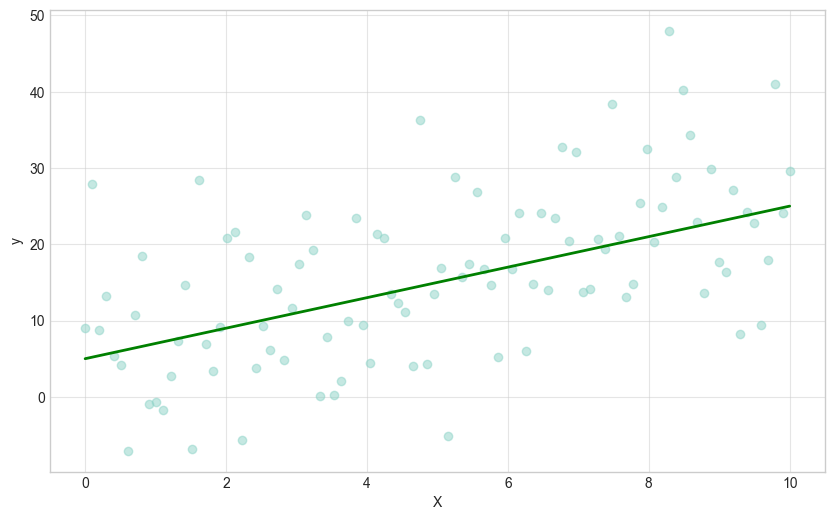

In [2]:
n_samples = 100

X = np.linspace(0, 10, n_samples).reshape(-1, 1)

noise = 10
y_true = 2*X + 5
y = y_true + noise * np.random.randn(n_samples, 1)

plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5)
plt.plot(X, y_true, color="green", linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.5)
plt.show()

In [3]:
# Creating and training model
reg_model = LinearRegression()
reg_model.fit(X, y)

y_pred = reg_model.predict(X)

# Metrics evaluation
mse = mean_squared_error(y, y_pred)
r2 = r2_score(y, y_pred)

print(f"Model coefficients: {reg_model.coef_[0][0]:.4f}")
print(f"Model intercept: {reg_model.intercept_[0]:.4f}")
print(f"Mean squared error: {mse:.4f}")
print(f"R2 score: {r2:.4f}")

Model coefficients: 2.1193
Model intercept: 5.3499
Mean squared error: 85.4509
R2 score: 0.3089


C:\Users\ana\AppData\Local\Temp\ipykernel_12828\983168245.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


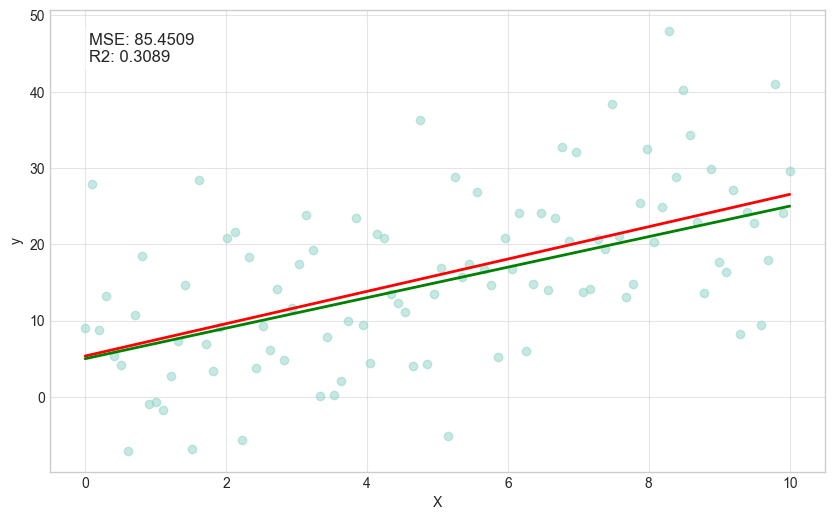

In [4]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.5)
plt.plot(X, y_pred, color="red", linewidth=2)
plt.plot(X, y_true, color="green", linewidth=2)
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.5)

plt.text(
    0.05, 0.95,
    f"MSE: {mse:.4f}\nR2: {r2:.4f}",
    transform=plt.gca().transAxes,
    fontsize=12,
    verticalalignment="top",
    bbox=dict(facecolor="white", boxstyle="round", alpha=0.5)
)
plt.show()

In [7]:
# MLFlow for tracking

import mlflow
import mlflow.sklearn
mlflow.set_tracking_uri("sqlite:///1_MLFlow_Gerenciamento_/mlflow.db")

EXPERIMENT_NAME = "hello-world-mlflow"
mlflow.set_experiment(EXPERIMENT_NAME)

2026/03/09 13:52:05 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/09 13:52:05 INFO mlflow.store.db.utils: Updating database tables
2026/03/09 13:52:06 INFO mlflow.tracking.fluent: Experiment with name 'hello-world-mlflow' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:C:/Users/ana/Documents/Cursos/warmUpFIAP/1_MLFlow_Gerenciamento_/mlruns/1', creation_time=1773075126907, experiment_id='1', last_update_time=1773075126907, lifecycle_stage='active', name='hello-world-mlflow', tags={}, workspace='default'>

In [8]:
noise_levels = [5, 10, 20]

for noise_level in noise_levels:
    n_samples = 100
    X = np.linspace(0, 10, n_samples).reshape(-1, 1)

    y_true = 2*X + 5
    y = y_true + noise * np.random.randn(n_samples, 1)

    with mlflow.start_run(run_name=f"noise_{noise_level}"):
        print(f"Running with noise level: {noise_level}")

        # Registrying parameters
        mlflow.log_param("noise_level", noise_level)
        mlflow.log_param("n_samples", n_samples)

        reg_model = LinearRegression()
        reg_model.fit(X, y)

        # Creating and training model
        reg_model = LinearRegression()
        reg_model.fit(X, y)

        y_pred = reg_model.predict(X)

        # Metrics evaluation
        mse = mean_squared_error(y, y_pred)
        r2 = r2_score(y, y_pred)

        mlflow.log_metric("mse", mse)
        mlflow.log_metric("r2", r2)
        mlflow.log_metric("coeficient", reg_model.coef_[0][0])
        mlflow.log_metric("intercept", reg_model.intercept_[0])

        plt.figure(figsize=(10, 6))
        plt.scatter(X, y, alpha=0.5)
        plt.plot(X, y_pred, color="red", linewidth=2)
        plt.plot(X, y_true, color="green", linewidth=2)
        plt.xlabel("X")
        plt.ylabel("y")
        plt.legend()
        plt.grid(True, alpha=0.5)

        plt.text(
            0.05, 0.95,
            f"MSE: {mse:.4f}\nR2: {r2:.4f}",
            transform=plt.gca().transAxes,
            fontsize=12,
            verticalalignment="top",
            bbox=dict(facecolor="white", boxstyle="round", alpha=0.5)
        )
        plt.savefig(f"regressao_linear.png")
        plt.close()

        mlflow.sklearn.log_model(reg_model, "reg_model")
        mlflow.log_artifact(f"regressao_linear.png")

        print(f"MSE: {mse:.4f}\nR2: {r2:.4f}\n")
        print(f"Run ID: {mlflow.active_run().info.run_id}\n")
        print("-" * 50)


Running with noise level: 5


C:\Users\ana\AppData\Local\Temp\ipykernel_12828\3748658113.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
2026/03/09 13:52:09 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/09 13:52:09 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
C:\Users\ana\AppData\Local\Temp\ipykernel_12828\3748658113.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt

MSE: 123.2782
R2: 0.1957

Run ID: e60ed666fda74a0c9d0f9ee9ea622de3

--------------------------------------------------
Running with noise level: 10


2026/03/09 13:52:15 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
C:\Users\ana\AppData\Local\Temp\ipykernel_12828\3748658113.py:41: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()
2026/03/09 13:52:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


MSE: 93.2236
R2: 0.3325

Run ID: e30452351b2b47ffb88d82fac22bbde7

--------------------------------------------------
Running with noise level: 20


2026/03/09 13:52:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


MSE: 120.0673
R2: 0.2870

Run ID: 510942652a964caf9e487561ba7fe64b

--------------------------------------------------
